### Mall Customer Segmentation 분석 - Clustering

- 쇼핑몰 고객의 나이 , 연간 수입 , 소비 점수를 기반으로 유사한 성향을 가진 고객들을 그룹(Cluster)으로 묶는 프로젝트
- 머신러닝 비지도학습 중 K-Means Clustering

### 주요 변수 정의
1. **Gender**: 성별 (Male / Female) - 범주형 변수
2. **Age**: 나이 - 수치형 변수
3. **Annual Income (k$)**: 연간 수입 (단위: 천 달러) - 수치형 변수
4. **Spending Score (1-100)**: 소비 점수 (쇼핑몰에서 매긴 고객의 소비 성향/빈도 점수, 높을수록 소비 성향 강함) - 수치형 변수

In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

from sklearn.cluster import KMeans 
from sklearn.metrics import confusion_matrix ,silhouette_score

from sklearn.decomposition import PCA # decomposition : 분해 
# 차원 축소 

# 시각화 
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 패치 표준

plt.rcParams['font.family'] = 'Malgun Gothic' # apple : 'AppleGothic'

# 마이너스 부호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [2]:
df_raw = pd.read_csv("./data/Mall_Customers.csv")
df_raw.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
selected_cols = ['Gender','Age','Annual Income (k$)','Spending Score (1-100)']
df = df_raw.copy(selected_cols)
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [5]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

### **** 데이터 분포 확인

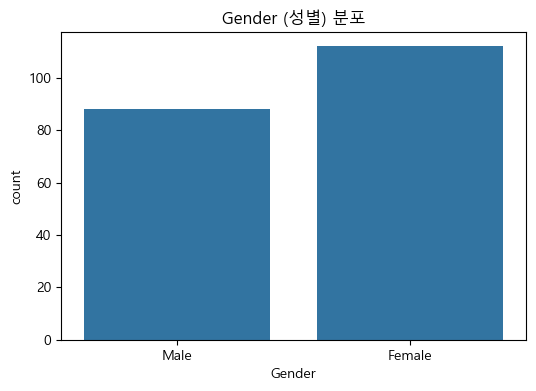

In [6]:
plt.figure(figsize = (6,4))
sns.countplot(x='Gender',data=df)
plt.title('Gender (성별) 분포')
plt.show()

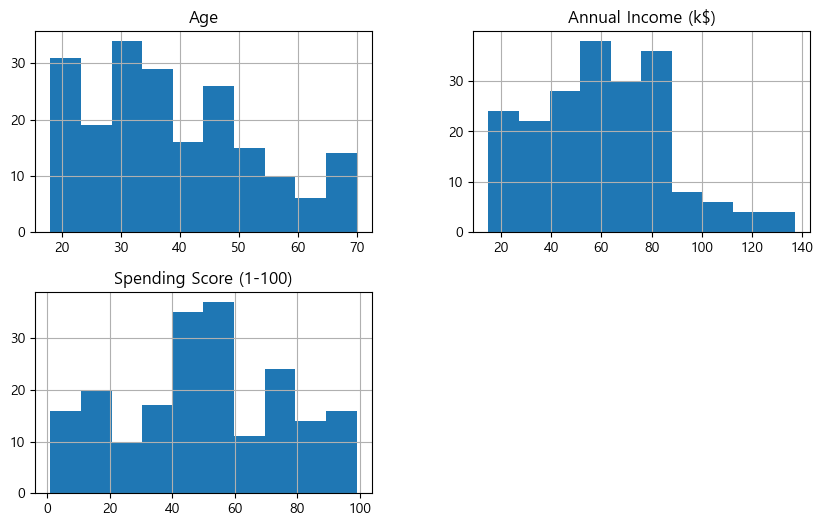

In [24]:
df[['Age','Annual Income (k$)','Spending Score (1-100)']].hist(figsize=(10,6))
plt.show()

- 데이터 범위가 맞지 않음 --> 표준화 스케일링 필요 

### *** 데이터 연관성 확인 ***

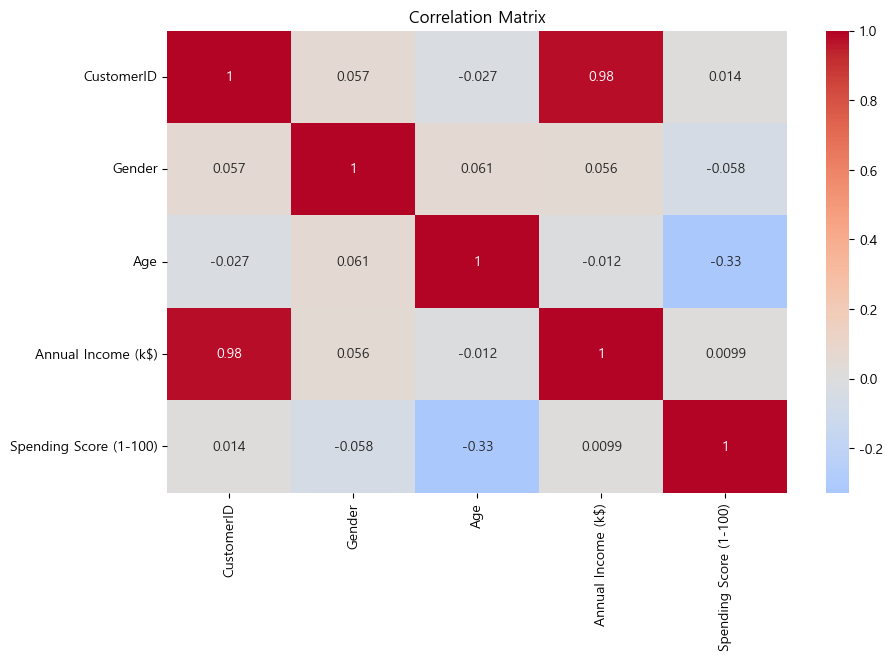

In [8]:
df_encoded = df.copy()
for col in df_encoded.select_dtypes(include=['object']).columns:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
correlation_matrix = df_encoded.corr()
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

In [37]:
# df['Gender_label'] = le.fit_transform(df['Gender'])
# df.head()

In [38]:
X = df[['Age','Annual Income (k$)','Spending Score (1-100)']].copy()
feature_names = X.columns.tolist()
X.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [39]:
# 변수를 평균 0, 표준편차 1 기준으로 변환
X_scaled = scaler.fit_transform(X)
scaled_df = pd.DataFrame(X_scaled,columns=feature_names)
print(scaled_df.agg(['mean','std']).round(4))

         Age  Annual Income (k$)  Spending Score (1-100)
mean -0.0000             -0.0000                 -0.0000
std   1.0025              1.0025                  1.0025


In [21]:
inertias = [] # 기울기 폭이 급격히 줄어드는 수치?
silhouette_list=[]

K_range = range(2, 11) # 통상 3개~4개 쪼갬 

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10  # KMeans는 서로 다른 초기중심점으로 몇번 반복 실행할지를 결정하는 값 
        # 서로 다른 중심점 초기값 _ 10 안으로 초기값 설정 
    )

    labels = kmeans.fit_predict(X_scaled)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

    # Silouette Score 계산 
    silhouette_list.append(silhouette_score(X_scaled,labels))
    
silhouette_df = pd.DataFrame({
    "K" : list(K_range),
    "Silhouette_Score" : silhouette_list
})

elbow_df = pd.DataFrame({
    "K": list(K_range),
    "Inertia": inertias
})

C:\Users\cyj\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\cyj\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\cyj\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\cyj\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than avai

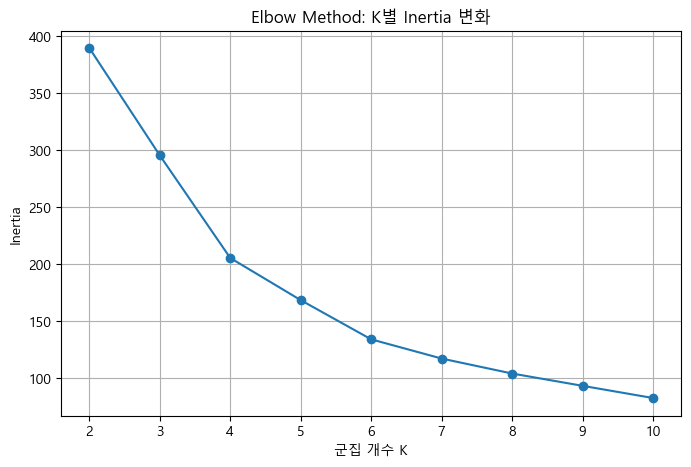

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(elbow_df["K"], elbow_df["Inertia"], marker="o")
plt.xlabel("군집 개수 K")
plt.ylabel("Inertia")
plt.title("Elbow Method: K별 Inertia 변화")
plt.xticks(list(K_range))
plt.grid()
plt.show()

n_clusters = 4 에서 기울기가 변화가 큼

In [32]:
kmeans_final = KMeans(
        n_clusters=4,
        random_state=42,
        n_init=10  # KMeans는 서로 다른 초기중심점으로 몇번 반복 실행할지를 결정하는 값 
        # 서로 다른 중심점 초기값 _ 10 안으로 초기값 설정 
    )

kmeans_final.fit(X_scaled)

df['Cluster'] = kmeans_final.fit_predict(X_scaled)
print(df['Cluster'].value_counts())

Cluster
0    65
2    57
1    40
3    38
Name: count, dtype: int64


C:\Users\cyj\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\cyj\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


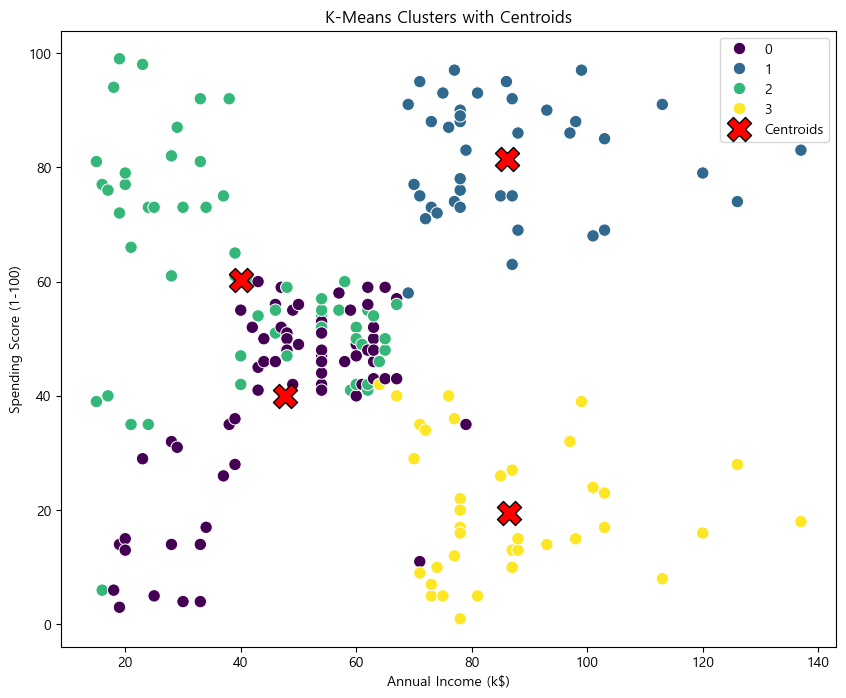

In [41]:
plt.figure(figsize=(10,8))
sns.scatterplot(data=df,x='Annual Income (k$)',y='Spending Score (1-100)',
                hue = 'Cluster' , palette='viridis', s=80)

centroids_scaled = kmeans_final.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)
centroids_df = pd.DataFrame(centroids_original, columns = feature_names)

plt.scatter(centroids_df['Annual Income (k$)'], centroids_df['Spending Score (1-100)'],
           marker = 'X',s=300,color='red',label='Centroids',edgecolor='k')

plt.title('K-Means Clusters with Centroids')
plt.legend()
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

[ 연소득 : X ] 
- 왼쪽 -> 소득 낮음
- 오른쪽 -> 소득 높음

[ 소비점수 : y ]
- 아래쪽 : 소비성향 낮음
- 위쪽 : 소비성향 높음

[ 전체 해석 ] 
- 우상단 : 소득 높고 , 소비도 높음
- 우하단 : 소득 높지만 , 소비는 낮음
- 좌상단 : 소득 낮지만 소비는 높음
- 좌하단 : 소득도 낮고 , 소비도 낮음
- 가운데 : 평균적인 고객층

[ 비지도 학습을 통한 데이터 인사이트 도출 ]

- Cluster 0 : 좌하단~중간 , 저소득/중간소득 + 저소비 =>  일반 고객 또는 소극적 소비 고객

- Cluster 1 : 고소득 + 고소비 => 핵심 VIP 고객군
  => VIP 멤버십 강화 , 프리미엄 상품 추천, 한정판 상품 제안, 개인 맞춤형 서비스 , 우수 고객 전용 혜택
  
- Cluster 2 : 좌상단~중간 , 저소득/중간소득 + 고소비 => 가격에는 민감하지만 구매의지는 높음 , 유치 필요 ,

- Cluster 3 : 고소득 + 저소비 => 구매여력은 있지만 소비가 낮은 고객 ( VIP 마케팅 대상 )
  => 프리미엄 상품 체험권 , 개인화 추천 , 첫 구매 혜택 